In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib 
from tqdm.notebook import tqdm
import copy

import pandas as pd
import xarray as xr

import torch.nn as nn
import torch.optim as optim
import random
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score


In [33]:
%%bash
jupyter nbconvert --to notebook \
  --TagRemovePreprocessor.enabled=True \
  --TagRemovePreprocessor.remove_cell_tags='["Correction", "Main"]' \
  --output ../exercises_notebooks/NN_example_student.ipynb NN_example_main.ipynb

jupyter nbconvert --to notebook \
  --TagRemovePreprocessor.enabled=True \
  --TagRemovePreprocessor.remove_cell_tags='["Student", "Main"]' \
  --output ../solutions_notebooks/NN_example_solution.ipynb NN_example_main.ipynb

[NbConvertApp] Converting notebook NN_example_main.ipynb to notebook
[NbConvertApp] Writing 39960 bytes to ../exercises_notebooks/NN_example_student.ipynb
[NbConvertApp] Converting notebook NN_example_main.ipynb to notebook
[NbConvertApp] Writing 129443 bytes to ../solutions_notebooks/NN_example_solution.ipynb


In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device!='cuda':
    print("Pytorch is running on cpu!")

# Load data

In [4]:
df = xr.open_dataset('../../projects/RiverStreamflow/data/61X13X0.nc',).to_dataframe().dropna().loc['2012':]
df = (df-df.mean())/df.std()

# Define inputs and ouputs

In [5]:
X = df[['air_pressure_at_sea_level','low_type_cloud_area_fraction',
        'relative_humidity_2m',
       'surface_net_longwave_radiation', 'surface_net_shortwave_radiation',
        'precipitation_amount_hourly',
       'wind_direction', 'wind_speed', 
       'medium_type_cloud_area_fraction']]
y = df['air_temperature_2m']
X = X.values
y = y.values
print(f"Shape of numpy array X: {X.shape}")
print(f"Shape of numpy array y: {y.shape}")

Shape of numpy array X: (112686, 9)
Shape of numpy array y: (112686,)


### Create tensors

Pytorch works with tensors, which are analogue to numpy arrays but also store gradients. From the numpy data provided above, create tensors 

In [6]:
X_tensor = ...
y_tensor = ...

In [11]:
X_tensor = torch.tensor(X,  dtype=torch.float32).to(device)
y_tensor = torch.tensor(y,  dtype=torch.float32).to(device)
y_tensor = y_tensor.reshape(-1, 1)

# Split train and test data

In [8]:
X_train, X_test, y_train, y_test  = ...

TypeError: cannot unpack non-iterable ellipsis object

In [12]:
X_train, X_test, y_train, y_test  = train_test_split(X_tensor, y_tensor, test_size=0.33, random_state=42)

# Design network

In [13]:
class MultiLayerPerceptron(nn.Module):
    def __init__(self, number_input_features, number_predictions):
        super().__init__()
        
        self.number_input_features = number_input_features
        self.number_predictions = number_predictions
        
        self.flatten = nn.Flatten()
        
        self.linear_relu_stack = nn.Sequential(
            # Layer 1
            nn.Linear(self.number_input_features, 16),
            nn.ReLU(),
            # Layer 2
            nn.Linear(16, 16),
            nn.ReLU(),
            # Layer 3
            nn.Linear(16, self.number_predictions),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [14]:
n_features = ...
n_predictions = ...
model = ...

In [27]:
n_features = X_tensor.shape[1]
n_predictions = 1
model = MultiLayerPerceptron(number_input_features=n_features, number_predictions=n_predictions)
model = model.to(device)

In [28]:
# training parameters
n_epochs = 100  # number of epochs to run
batch_size = 256  # size of each batch
learning_rate = 0.002  # size of each batch
index_where_batches_start = torch.arange(0, len(X_train), batch_size)

loss_fn = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Train network

In [29]:
# We keep the weights and biases of the best model
best_mse = np.inf   # initialise to infinity
best_weights = None
history = []

# training loop
for epoch in tqdm(range(n_epochs)):
    model.train()
    for start in index_where_batches_start:
        # Select the batch of data
        X_batch = X_train[start:start+batch_size]
        y_batch = y_train[start:start+batch_size]
        # forward pass: make the prediction and compute the loss    
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)      
        # backward pass: compute gradients to know how to change weights
        optimizer.zero_grad()
        loss.backward()
        # update weights
        optimizer.step()
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test)
    mse = loss_fn(y_pred, y_test).detach()
    mse = float(mse)
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())

# restore model and return best accuracy
model.load_state_dict(best_weights)
model = model.eval()


  0%|          | 0/100 [00:00<?, ?it/s]

###  Plot training history: verify that the loss function goes down

MSE: 0.48
RMSE: 0.69


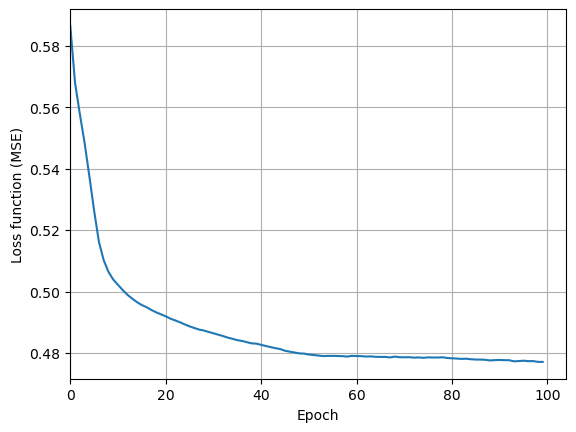

In [30]:
with torch.no_grad():
    best_pred = model(X_test).detach().cpu()


fix, ax = plt.subplots()
# ax.set_ylim(0,None)
print("MSE: %.2f" % best_mse)
print("RMSE: %.2f" % np.sqrt(best_mse))
ax.plot(history)
ax.set_ylabel('Loss function (MSE)')
ax.set_xlabel('Epoch')
ax.set_xlim(0,None)
ax.grid()
plt.show()

# Evaluate model

(np.float64(-3.2421905279159544),
 np.float64(4.4966885328292845),
 np.float64(-3.077105689048767),
 np.float64(3.3423725843429564))

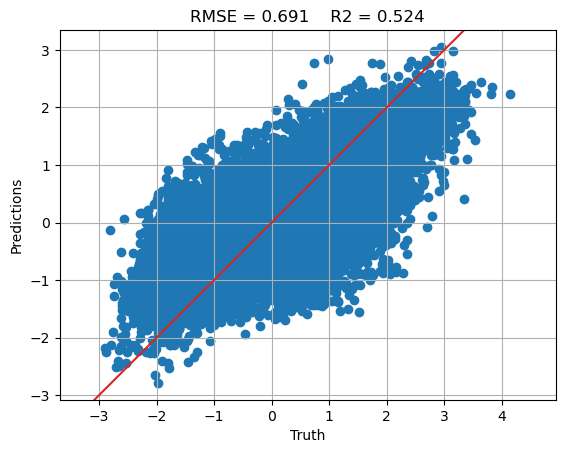

In [31]:
# Compute scores for the model
rmse_score = root_mean_squared_error(y_test.cpu(), best_pred)
r2 = r2_score(y_test.cpu(), best_pred)


# Plot the results
fig, ax = plt.subplots()
ax.scatter(y_test.cpu(), best_pred)
ax.axline((0,0), slope=1, color='C3')
ax.set_ylabel('Predictions')
ax.set_xlabel('Truth')
ax.set_title(f"RMSE = {rmse_score:.03f}    R2 = {r2:.03f}")
ax.grid()
ax.axis('equal')
# Best with simple data: 0.260
# Best R2: 0.790

In [133]:
# Compute metrics to evaluate the model
...

# Plot the results
...

# Compare with a simple linear model

Text(0.5, 1.0, 'RMSE = 0.797    R2 = 0.365')

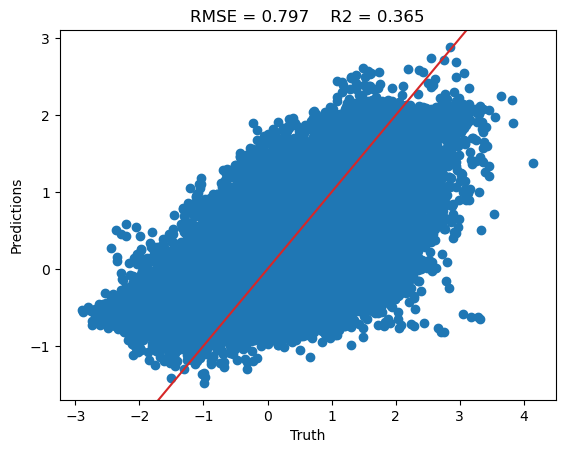

In [32]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train.cpu(), y_train.cpu())


y_pred_linear = linear_model.predict(X_test.cpu())

    
fig, ax = plt.subplots()
ax.scatter(y_test.cpu(), y_pred_linear)
ax.axline((0,0), slope=1, color='C3')
ax.set_ylabel('Predictions')
ax.set_xlabel('Truth')

rmse_score = root_mean_squared_error(y_test.cpu(), y_pred_linear)
r2 = r2_score(y_test.cpu(), y_pred_linear)
ax.set_title(f"RMSE = {rmse_score:.03f}    R2 = {r2:.03f}")

# SVM is close to NN but still worse


In [144]:
n_features = np.prod(X_train.shape[1:])
X_train_linear = X_train.cpu().reshape(-1, n_features)
X_test_linear = X_test.cpu().reshape(-1, n_features)

...


Ellipsis